In [1]:
library(tidyverse)
library(dbplyr)
library(bigrquery)
library(lubridate)

bq_auth()

project_id = "yhcr-prd-bradfor-bia-core"

# create connection to database
con <- DBI::dbConnect(bigrquery::bigquery(), 
                      project = project_id)

print(paste0("Connected to : ", project_id))

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘dbplyr’


The following objects are masked from ‘package:dplyr’:

    ident, sql




[1] "Connected to : yhcr-prd-bradfor-bia-core"


In [2]:
person_ids <- read.csv('data/person_ids.csv', header = TRUE)

In [3]:
pupil_data = "CB_2489.cb_KS4Pupil_All"

In [4]:


pupil_table <- tbl(con, pupil_data) |>
    select(person_id, KS4_ATT8,KS4_P8SCORE, 
           KS4_ENTRIES, KS4_ENTRY_E_ALL_PTQ_EE,
           KS4_ENTRY_1_3NG_PTQ_EE, KS4_ENTRY_5_3NG_PTQ_EE, 
           KS4_PASS_LEV1_PTQ_EE, 
           KS4_BTEC_PTQ_EE, KS4_VOCQUAL_PTQ_EE,
           KS4_ANYPASS_PTQ_EE, 
           KS4_FINELEVEL_PTQ_EE,
           KS4_IDACI) 

In [5]:
entries_table <- tbl(con, pupil_data) |>
    select(person_id, KS4_ATT8,
           KS4_ENTRIES, KS4_ENTRY_E_ALL_PTQ_EE,
           KS4_KS2EMFG
           ) 

In [6]:
ks4_table <- tbl(con, pupil_data) |>
    select(person_id,  
           KS4_ENTRIES, 
           KS4_PASS_LEV1_PTQ_EE, 
           KS4_PASS_LEV2_PTQ_EE,
           KS4_IDACI) 

In [7]:
entries_df <- collect(entries_table)

In [8]:
pupil_df <- collect(pupil_table)

In [9]:
ks4_df <- collect(ks4_table)

In [10]:
head(pupil_df)

person_id,KS4_ATT8,KS4_P8SCORE,KS4_ENTRIES,KS4_ENTRY_E_ALL_PTQ_EE,KS4_ENTRY_1_3NG_PTQ_EE,KS4_ENTRY_5_3NG_PTQ_EE,KS4_PASS_LEV1_PTQ_EE,KS4_BTEC_PTQ_EE,KS4_VOCQUAL_PTQ_EE,KS4_ANYPASS_PTQ_EE,KS4_FINELEVEL_PTQ_EE,KS4_IDACI
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
5155E920BFE1B3D9F17E11F1C971EC8B1D7D17F0434C5DDA9A6B471F65069772,NA,NA,10,NA,NA,NA,NA,NA,NA,NA,NA,NA
33123AC91CA48A233EF78F6071277769B94FFB2F4395DC494559B677DC50DF7A,NA,NA,18,NA,NA,NA,NA,NA,NA,NA,NA,NA
3C1A4A6804FDFB4CEAB84D6B755649E364B05AABECB1E1C0DC85E2645B73FE71,NA,NA,1,NA,NA,NA,NA,NA,NA,NA,NA,NA
71F5932CCDF614111A5E5ABA8DF88F1AFC1A1CA0B1646710488CE3DCE86A8601,NA,NA,14,NA,NA,NA,NA,NA,NA,NA,NA,NA
C5BC4DF86AB485EB962FC6FC9B7E2534E8A393D4A9D0C30186FA42AC1ECC43E8,NA,NA,16,NA,NA,NA,NA,NA,NA,NA,NA,NA
87DFA098EA880CF6BDC3B0C87FFC9BEBE08FF7276818BA9960B719B8448FA301,NA,NA,14,NA,NA,NA,NA,NA,NA,NA,NA,NA


In [11]:
head(ks4_df)

person_id,KS4_ENTRIES,KS4_PASS_LEV1_PTQ_EE,KS4_PASS_LEV2_PTQ_EE,KS4_IDACI
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
3C1A4A6804FDFB4CEAB84D6B755649E364B05AABECB1E1C0DC85E2645B73FE71,1,NA,NA,NA
3F35C700D6B855296E9B0989C5C0CF28A4D45ABF7AFD5CD23ED26D20D2C56EE9,1,NA,NA,NA
7A57C38A01CFB2A1181EFC21C4B874847B12C16AF32959CE60D990C9112B238E,2,NA,NA,NA
15971B28334CD145F15287649516E94517BDF2DE8AD0860515F7B4756093AB71,1,NA,NA,NA
A1F96648C8F525A3D7C905DCD89AF4CB58A74A9EF31B70C1914826D32EADA668,1,NA,NA,NA
521881F3ACE00C19C6543B4CFE16B1082EBFC8ABCF081CC912F9B879DAC56ECE,1,NA,NA,NA


# Explore variables

KS4_ENTRIES: Total number of GCSE and equivalents entries (GCSE equivalencies). 

KS4_ENTRY_E_ALL_PTQ_EE: Total number of GCSE and equivalents entries (all S96 quals) under current methodology but all qualifications (ignore PTQ_INCLUDE flag)

KS4_KS2EMFG: KS2 prior attainment in English and mathematics

KS4_ENTRY_1_3NG_PTQ_EE: entered into at least 1 GCSE or equivalent. 
KS4_ENTRY_5_3NG_PTQ_EE: " 5

KS4_PASS_LEV1_PTQ_EE: Total number of Level 1 GCSE and equivalent qualifications (GCSE equivalencies). Level 1 qualifications, often achieved in Years 10 and 11 of secondary school, are equivalent to GCSE grades 1, 2, or 3 (formerly D, E, F, or G) and include qualifications like Level 1 Functional Skills or Essential Skills. 

KS4_PASS_LEV2_PTQ_EE: Total number of Level 2 GCSE and equivalent qualifications (GCSE equivalencies). Level 2 qualifications, equivalent to GCSE grades 9-4 (or A*-C in the old system), include Functional Skills Level 2, NVQ Level 2, and intermediate apprenticeships, among others. 

KS4_ANYPASS_PTQ_EE: Achieved any passes at all in GCSE or equivalents(inc S96, WOLF, first Entry and vocational qualification capping)

KS4_VOCQUAL_PTQ_EE: Flag to indicate if a learner has achieved at least one vocational qualification at KS4. 

KS4_BTEC_PTQ_EE: Number of BTECs achieved (NOT GCSE equivalencies).

KS4_FINELEVEL_PTQ_EE: Pupil Fine Level score

In [12]:
pupil_filtered <- pupil_df |>
    filter(person_id %in% person_ids$person_id) 

In [13]:
entries_filtered <- entries_df |>
    filter(person_id %in% person_ids$person_id) 

In [14]:
ks4_filtered <- ks4_df |>
    filter(person_id %in% person_ids$person_id) 

In [15]:
entries_filtered |> arrange(KS4_ATT8)

person_id,KS4_ATT8,KS4_ENTRIES,KS4_ENTRY_E_ALL_PTQ_EE,KS4_KS2EMFG
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
ED7C9A15365C9DD4A058CACEABDAB0AABA2059DC70D90F8E2019B94FFD82D630,0,0,0.00,0.0
878876BF2A273D1137B5002D5DC531D890FED06DDDA7D60E77D06E5393006BA0,0,2,1.00,0.0
CB916EAD89FBDEA2FD1C1C6065BCCC325C81661CCD8D0EC4CA1425A178839730,0,0,0.00,0.0
B310EBF8C3E27823D7AD4DC9FCD56A01BFA017119F8463E6139FC79D3A0D88B9,0,2,2.50,0.0
77D1D02195DBCA84A73FED0DCDEDA8F63C0627844F863A3A8A621E4BE1436A62,0,0,0.00,0.0
AD7199C8A854527D21D06DB78D72A5AB202DAA4B5D35C060BE0645C01733622B,0,0,0.00,0.0
EFD15AF1DC40D9AD51D029D27392CBB8DD4251FA32179D9C983E7ECDD0F806D2,0,0,0.00,0.0
2B2B862D37399A40F7D19A9649AAD1EE62357EF26FE3FAB23B64459E9FDC4E99,0,0,0.00,0.0
C04E26D4D5D27E56A5DB27CC0AF82D9581ED86BC760E8C2104A6AD67E43DC6A4,0,2,2.50,0.0


In [16]:
pupil_filtered |> arrange(KS4_ATT8)

person_id,KS4_ATT8,KS4_P8SCORE,KS4_ENTRIES,KS4_ENTRY_E_ALL_PTQ_EE,KS4_ENTRY_1_3NG_PTQ_EE,KS4_ENTRY_5_3NG_PTQ_EE,KS4_PASS_LEV1_PTQ_EE,KS4_BTEC_PTQ_EE,KS4_VOCQUAL_PTQ_EE,KS4_ANYPASS_PTQ_EE,KS4_FINELEVEL_PTQ_EE,KS4_IDACI
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
DA178A681ACD2F73D48BA25AEB3E9FF5715774CD4C5BC919F3B9EBADE552F95F,0,0,11,6.00,0,0,0,0,0,0,0,0.00
89171AED048B18ECFA971C3641E0783987CC8715CF510453C69F99706E6A548C,0,0,3,0.50,0,0,0,0,0,0,0,0.00
7C9BA2C62786A1321404A62974C44086484F4BCC2628124D57C07F5D5A7EFBBB,0,0,5,1.00,0,0,0,0,0,0,0,0.00
1C13D8CFB2CDF4B3A9A4E7166CB109247B25499EFA871B6FA8C0ACC6EF9B0196,0,0,6,1.50,0,0,0,0,0,0,0,0.00
E4D0478E2DC8027FCCFC61C49310F8051A5065B6CFEC566D3754B71DF59C5CC7,0,0,9,4.50,1,0,0,0,0,0,0,0.21
4C93D640B65B15D7B3E8B061F90D1D117BCB6447D8E01662DD7BA6CB227C9C75,0,0,5,2.25,0,0,0,0,0,0,0,0.00
FAD3ED69CABC0B2803E724E8C31742CE9570661B8E51865B7688B83DD86A79FA,0,0,5,2.00,0,0,0,0,0,0,0,0.00
3884EA9F48676F001E814A542819FAE951C6A3666AD64BD512474D52AB4390CD,0,0,7,0.50,0,0,0,0,0,0,0,0.39
8162139524FD12F229AA20ECC03197D4B0D3D4C5A45956ED65A5DC4F7CC39640,0,0,2,2.50,0,0,0,0,0,0,0,0.00


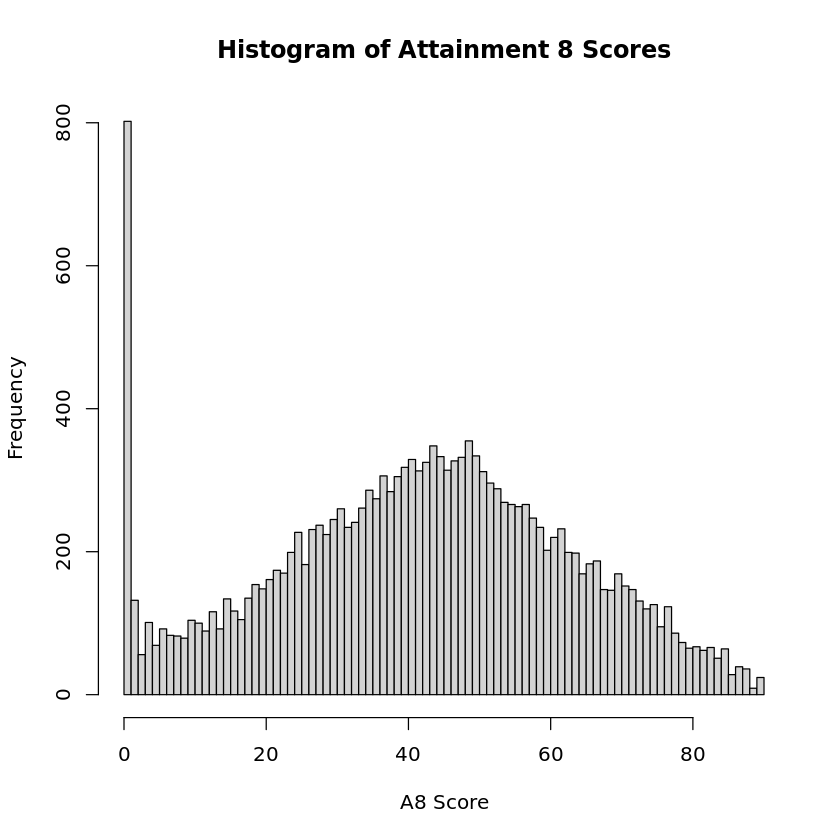

In [17]:
hist(pupil_filtered$KS4_ATT8, breaks = 100,
    main = "Histogram of Attainment 8 Scores", 
     xlab = "A8 Score")

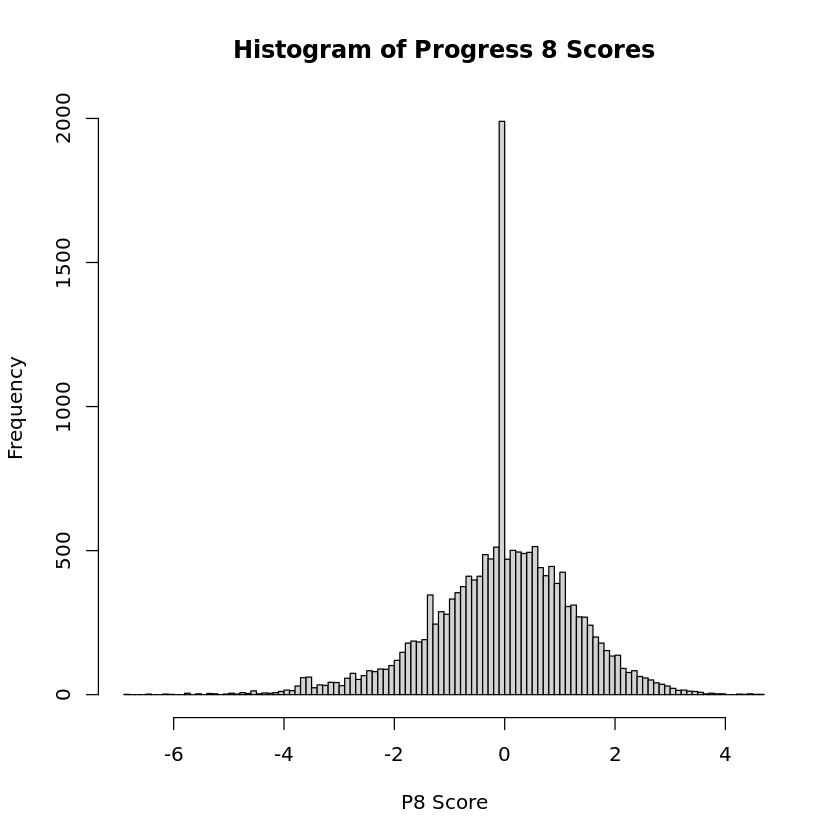

In [18]:
hist(pupil_filtered$KS4_P8SCORE, breaks = 100,
    main = "Histogram of Progress 8 Scores", 
     xlab = "P8 Score")

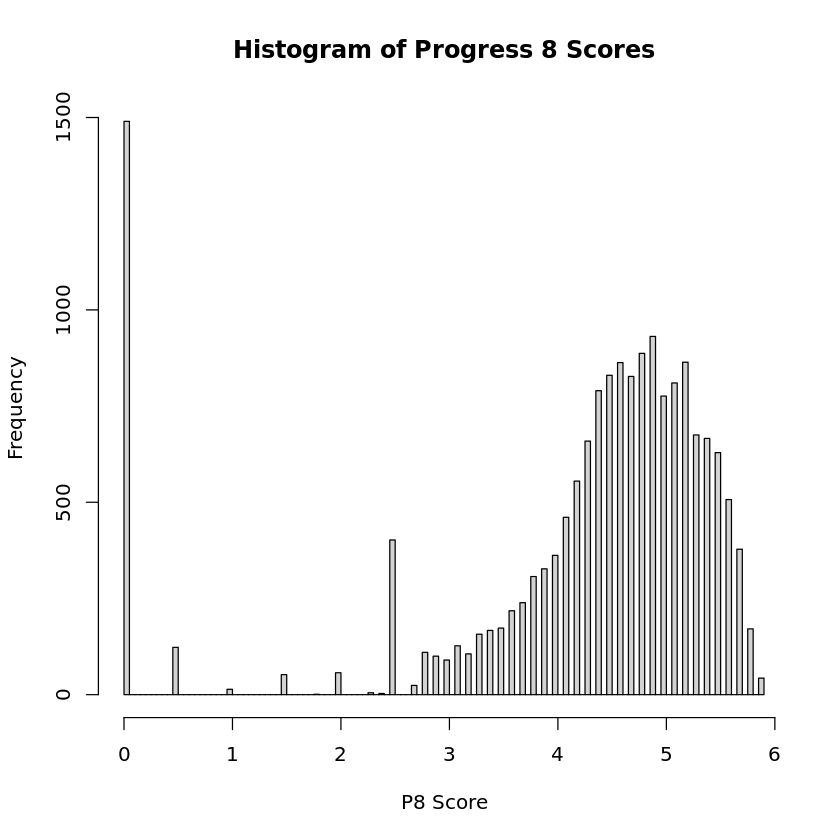

In [19]:
hist(pupil_filtered$KS4_FINELEVEL_PTQ_EE, breaks = 100,
    main = "Histogram of Progress 8 Scores", 
     xlab = "P8 Score")

In [20]:
head(entries_filtered)

person_id,KS4_ATT8,KS4_ENTRIES,KS4_ENTRY_E_ALL_PTQ_EE,KS4_KS2EMFG
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
ED7C9A15365C9DD4A058CACEABDAB0AABA2059DC70D90F8E2019B94FFD82D630,0,0,0.0,0
878876BF2A273D1137B5002D5DC531D890FED06DDDA7D60E77D06E5393006BA0,0,2,1.0,0
CB916EAD89FBDEA2FD1C1C6065BCCC325C81661CCD8D0EC4CA1425A178839730,0,0,0.0,0
B310EBF8C3E27823D7AD4DC9FCD56A01BFA017119F8463E6139FC79D3A0D88B9,0,2,2.5,0
77D1D02195DBCA84A73FED0DCDEDA8F63C0627844F863A3A8A621E4BE1436A62,0,0,0.0,0
AD7199C8A854527D21D06DB78D72A5AB202DAA4B5D35C060BE0645C01733622B,0,0,0.0,0


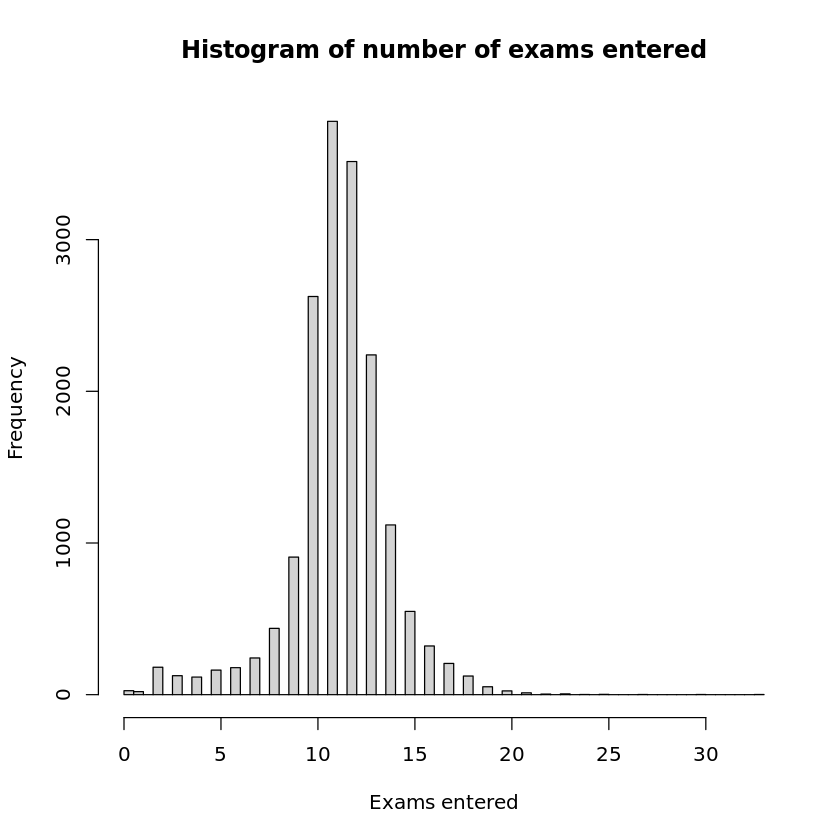

In [21]:
hist(entries_filtered$KS4_ENTRIES, breaks = 100,
    main = "Histogram of number of exams entered", 
     xlab = "Exams entered")

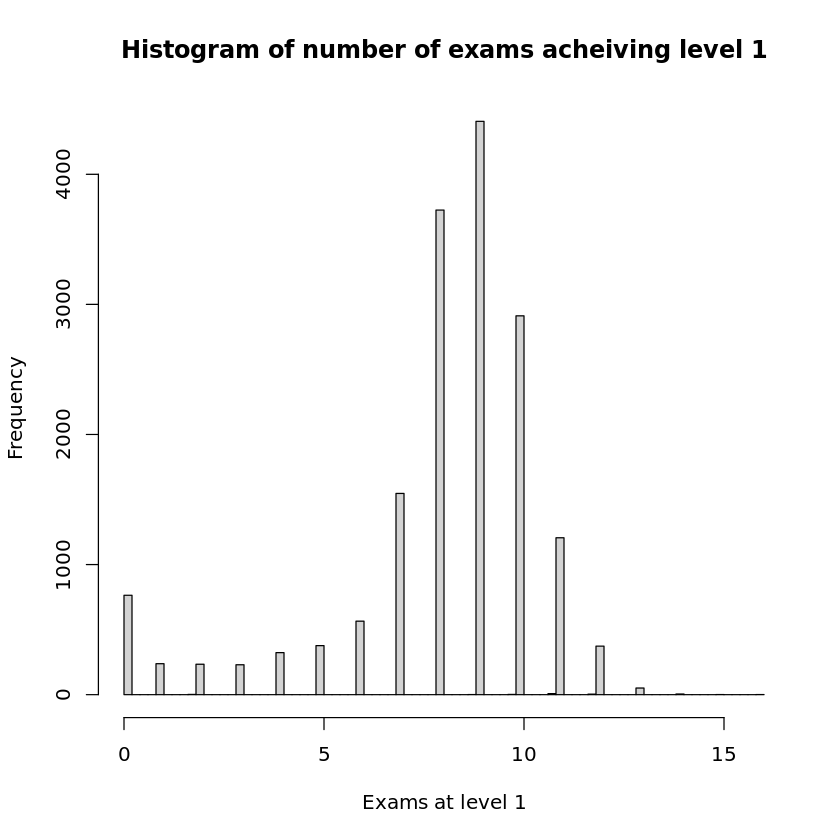

In [22]:
hist(pupil_filtered$KS4_PASS_LEV1_PTQ_EE, breaks = 100,
    main = "Histogram of number of exams acheiving level 1", 
     xlab = "Exams at level 1")

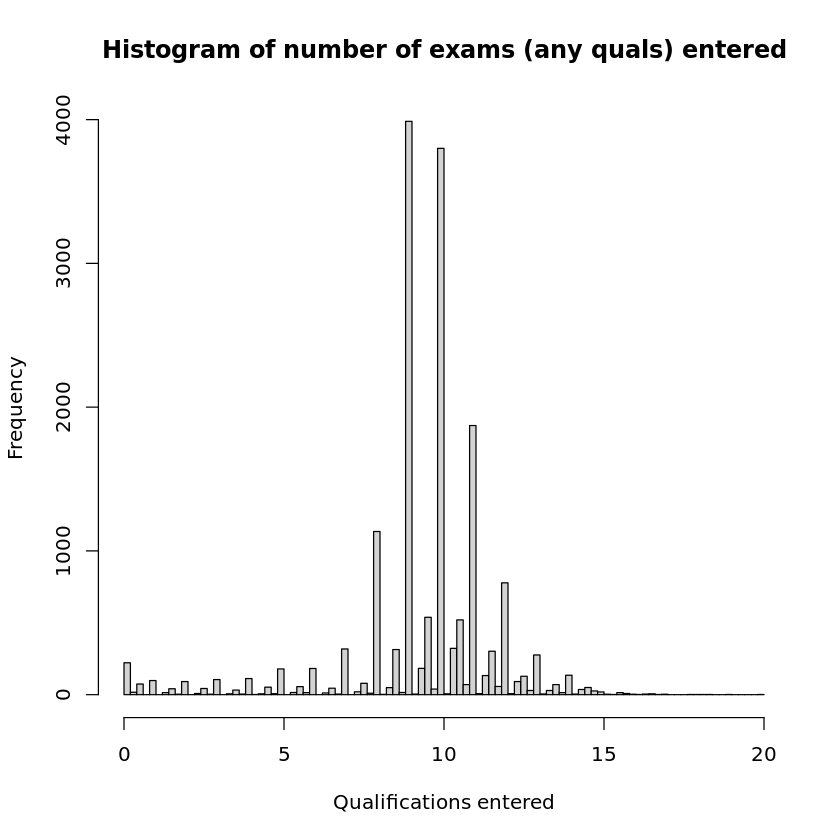

In [23]:
hist(entries_filtered$KS4_ENTRY_E_ALL_PTQ_EE, breaks = 100,
    main = "Histogram of number of exams (any quals) entered", 
     xlab = "Qualifications entered")

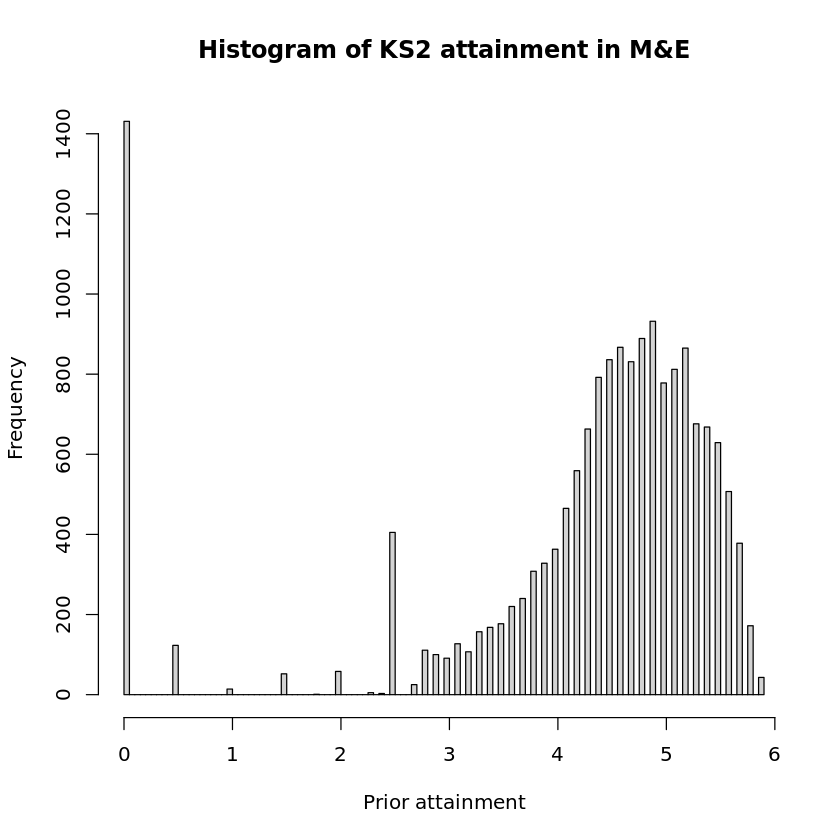

In [24]:
hist(entries_filtered$KS4_KS2EMFG, breaks = 100,
    main = "Histogram of KS2 attainment in M&E", 
     xlab = "Prior attainment")

# Visualise

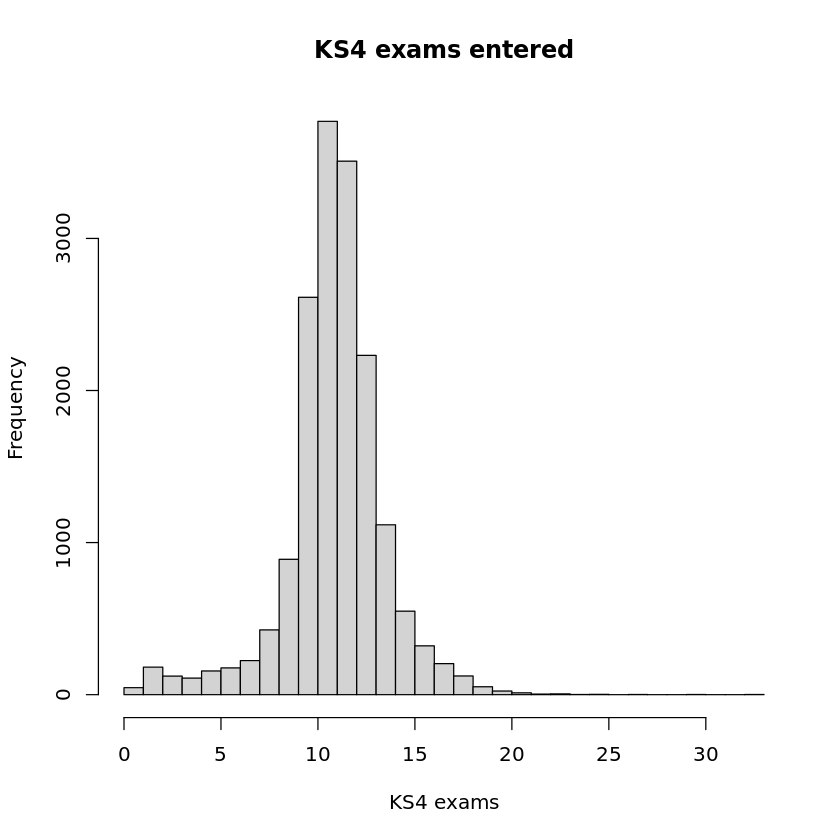

In [51]:
hist(ks4_filtered$KS4_ENTRIES, breaks = 33,
    main = "KS4 exams entered", 
     xlab = "KS4 exams")

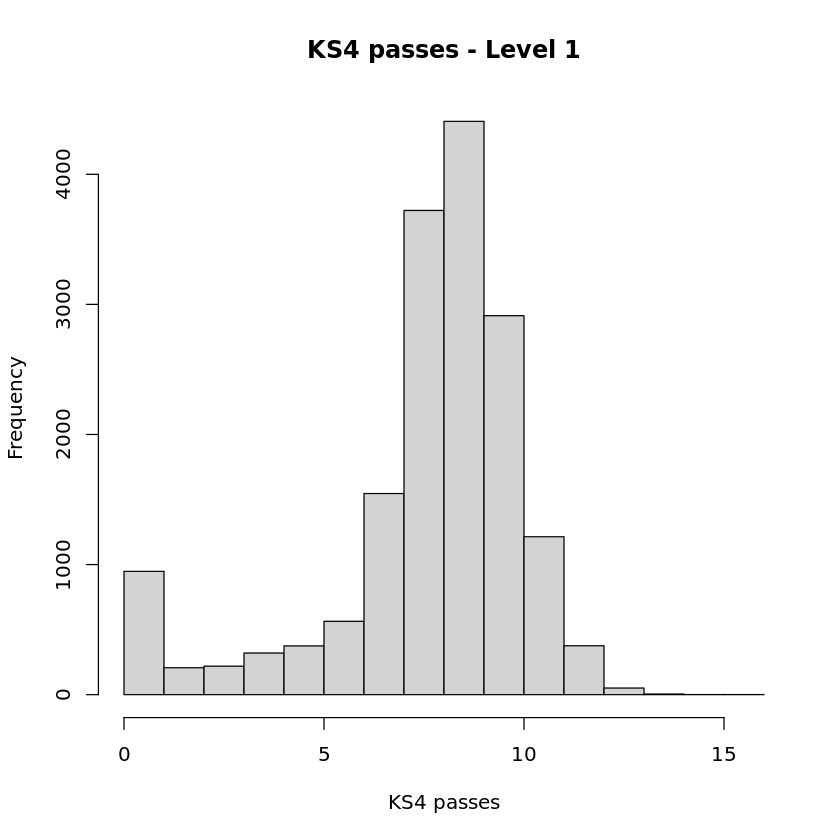

In [52]:
hist(ks4_filtered$KS4_PASS_LEV1_PTQ_EE, breaks = 16,
    main = "KS4 passes - Level 1", 
     xlab = "KS4 passes")

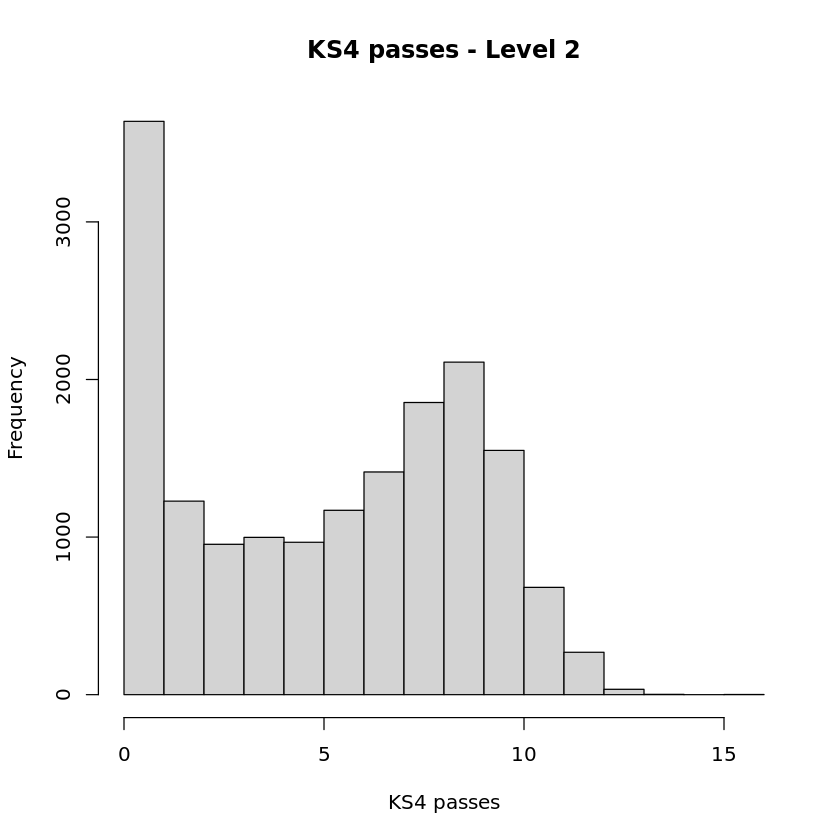

In [53]:
hist(ks4_filtered$KS4_PASS_LEV2_PTQ_EE, breaks = 16,
    main = "KS4 passes - Level 2", 
     xlab = "KS4 passes")

In [54]:
summary(ks4_filtered)

  person_id          KS4_ENTRIES    KS4_PASS_LEV1_PTQ_EE KS4_PASS_LEV2_PTQ_EE
 Length:16869       Min.   : 0.00   Min.   : 0.000       Min.   : 0.000      
 Class :character   1st Qu.:10.00   1st Qu.: 8.000       1st Qu.: 2.000      
 Mode  :character   Median :11.00   Median : 9.000       Median : 6.000      
                    Mean   :11.35   Mean   : 8.053       Mean   : 5.483      
                    3rd Qu.:13.00   3rd Qu.:10.000       3rd Qu.: 9.000      
                    Max.   :33.00   Max.   :16.000       Max.   :16.000      
   KS4_IDACI     
 Min.   :0.0000  
 1st Qu.:0.1000  
 Median :0.2300  
 Mean   :0.2236  
 3rd Qu.:0.3200  
 Max.   :0.7000  

#### exploring students who are recorded to have entered different numbers of exams...

In [38]:
ks4_filtered %>%
  count(person_id) %>%
  filter(n > 1)

person_id,n
<chr>,<int>
033AFCE41B7B4BAE7FDD133926D5DF895E98C5C43F4BFA8F52CD79F4DF1B60F7,2
06C599F294B1CFF6ED2F0945DBDFB2A8D21AD0E268732799792878D4A33D84E0,2
0A69F30C79C7050090460E9093EA1D5639D43AC626C3067E754604156142CA57,2
0A95DF5BA191CED6A61035D391F33433FC94CB07AF956305B6DF22DA83F10B3E,2
0C7117F4328D8C71A2C74E9F7A4DC0B9F092A07D4204507CAC93FA94CB015185,2
0F719CE1354E346BC9788D861696C41D3E12CD4E9B922C321905506B99B7F517,2
14CC9C7A7762FA67C0A66E211EC9CCEB6CBD14C2B2AE3B6694D0DBCB488BBF62,2
14D41C0A8B8005B01D6A5E50B79D9DFD7F234A0620D5553BFDDBD445C2F69CCA,2
197739B330DCFC024B66615A0BA3C4DF10389D593D2D669EF5AB3EDDDEB69339,2


In [44]:
ks4_df |>
    filter(person_id == '38C38B72800AB59D24A9677F19DB0C3872F37209D24BC03DA9F68E7543CF333F')

person_id,KS4_ENTRIES,KS4_PASS_LEV1_PTQ_EE,KS4_PASS_LEV2_PTQ_EE,KS4_IDACI
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
41575FE42DA6B272470FEA39331A0B495AE7F1F5BD8CFFC479C64F3FB04C5504,8,0,0,0.13
41575FE42DA6B272470FEA39331A0B495AE7F1F5BD8CFFC479C64F3FB04C5504,11,0,0,0.00


In [47]:
pupil_df |>
    filter(person_id == '38C38B72800AB59D24A9677F19DB0C3872F37209D24BC03DA9F68E7543CF333F')

person_id,KS4_ATT8,KS4_P8SCORE,KS4_ENTRIES,KS4_ENTRY_E_ALL_PTQ_EE,KS4_ENTRY_1_3NG_PTQ_EE,KS4_ENTRY_5_3NG_PTQ_EE,KS4_PASS_LEV1_PTQ_EE,KS4_BTEC_PTQ_EE,KS4_VOCQUAL_PTQ_EE,KS4_ANYPASS_PTQ_EE,KS4_FINELEVEL_PTQ_EE,KS4_IDACI
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
38C38B72800AB59D24A9677F19DB0C3872F37209D24BC03DA9F68E7543CF333F,3,0.000,10,9.5,1,0,2,0,0,1,0.0,0.0
38C38B72800AB59D24A9677F19DB0C3872F37209D24BC03DA9F68E7543CF333F,3,-2.946,7,4.5,1,0,2,0,0,1,4.1,0.5


In [46]:
entries_df |>
    filter(person_id == '41575FE42DA6B272470FEA39331A0B495AE7F1F5BD8CFFC479C64F3FB04C5504')

person_id,KS4_ATT8,KS4_ENTRIES,KS4_ENTRY_E_ALL_PTQ_EE,KS4_KS2EMFG
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
41575FE42DA6B272470FEA39331A0B495AE7F1F5BD8CFFC479C64F3FB04C5504,0,8,3.5,2.8
41575FE42DA6B272470FEA39331A0B495AE7F1F5BD8CFFC479C64F3FB04C5504,0,11,6.5,0.0


In [33]:
entries_filtered |>
    filter(person_id == '0A95DF5BA191CED6A61035D391F33433FC94CB07AF956305B6DF22DA83F10B3E')

person_id,KS4_ATT8,KS4_ENTRIES,KS4_ENTRY_E_ALL_PTQ_EE,KS4_KS2EMFG
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
0A95DF5BA191CED6A61035D391F33433FC94CB07AF956305B6DF22DA83F10B3E,0,14,6.5,0
0A95DF5BA191CED6A61035D391F33433FC94CB07AF956305B6DF22DA83F10B3E,0,6,2.5,0


In [48]:
ks4_filtered <- ks4_filtered |>
  group_by(person_id) |>
  filter(n() == 1 | KS4_ENTRIES == min(KS4_ENTRIES)) |>
  ungroup()

In [50]:
ks4_filtered

person_id,KS4_ENTRIES,KS4_PASS_LEV1_PTQ_EE,KS4_PASS_LEV2_PTQ_EE,KS4_IDACI
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
8162139524FD12F229AA20ECC03197D4B0D3D4C5A45956ED65A5DC4F7CC39640,2,0,0,0.00
B1FB0FCF737FA4E17FF717DBAE7055474EFDCC3B28A495DF554205A667D406DE,2,0,0,0.00
6B8EB0F5C99DD20853DA0B987C4910FABDF0D0957CCCB4F85103102EE325822D,2,0,0,0.00
C39E61EAFEAF90E7EC3EC092BAD9FA5A47E94A889790FC29C0B0E7F0C6989574,2,0,0,0.00
8C8B14978AE28DEF988E73CE511765B70921FB9C06EB9CB2D2D6F9AF459B167C,0,0,0,0.00
259BF856FEF2FC42D931FC5AF6A310188A0D1C7501345FB78DD585BE68B46840,1,0,0,0.00
9CE324B0A90E74CBF46009E89B1AAD072B5A8D4E2D47B7E87BF8DCB6E008E8F4,2,0,0,0.00
E35E5EC48AFDB69D9FCF39B8448E44AA7C20E331414BBF1BEAF4F03C6852390B,0,0,0,0.00
8008F4DA6D4B083798F67438CA9C124985655AB4C7A4EEA5F73ED8F690F148FC,2,0,0,0.00


# Save to csv

In [49]:
write.csv(ks4_filtered, "data/ks4_filtered.csv", row.names = FALSE)